# 13. Analisis de consistencia temporal

Este notebook mide si la pseudo-LiDAR generada en frames consecutivos es coherente cuando se usa la transformacion real de nuScenes.

Idea principal:
- se toma la pseudo-LiDAR del frame `t`,
- se transforma al sistema del frame `t+1` usando la pose real,
- se compara contra la pseudo-LiDAR generada directamente en `t+1`,
- se calculan distancias nearest-neighbor y ratios de solape.

Mensaje importante: antes de evaluar el registro estimado por ICP, se analiza si la pseudo-LiDAR es geometricamente coherente entre frames cuando se usa la transformacion real de nuScenes. Esto permite separar errores de la representacion pseudo-LiDAR de errores introducidos por ICP.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.options.display.float_format = '{:.3f}'.format

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
BASE_DIR = ROOT / 'outputs' / 'scene-0061'
SCRIPT_PATH = ROOT / 'scripts' / 'evaluate_temporal_consistency.py'
OUTPUT_PATH = BASE_DIR / 'temporal_consistency_metrics.json'
CSV_PATH = BASE_DIR / 'temporal_consistency_by_region.csv'
FIGURE_PATH = BASE_DIR / 'temporal_consistency_by_region.png'

ROOT, BASE_DIR

(PosixPath('/home/clara/ml-depth-pro/slam_readiness_nuscenes'),
 PosixPath('/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061'))

## Ejecutar o cargar resultados

Si el JSON ya existe, se carga directamente. Si no existe y la variable `NUSCENES_ROOT` esta definida, el notebook ejecuta el script reproducible.

In [2]:
if not OUTPUT_PATH.exists():
    nuscenes_root = os.environ.get('NUSCENES_ROOT')
    if nuscenes_root is None:
        raise RuntimeError('No existe temporal_consistency_metrics.json y NUSCENES_ROOT no esta definido.')
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        '--run-summary', str(BASE_DIR / 'run_summary.json'),
        '--dataroot', nuscenes_root,
        '--version', 'v1.0-mini',
        '--output', str(OUTPUT_PATH),
    ]
    print(' '.join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'El analisis de consistencia temporal ha fallado con codigo {result.returncode}')

temporal = json.loads(OUTPUT_PATH.read_text(encoding='utf-8'))
rows = pd.read_csv(CSV_PATH)
print('Pares evaluados:', temporal['num_pairs'])
print('Regiones:', ', '.join(temporal['regions']))

Pares evaluados: 4
Regiones: all, front, near, mid, far, left, right


## Resultados por par y region

Cada fila corresponde a un par consecutivo de frames y a una region espacial. `mean_nn_m`, `median_nn_m` y `p90_nn_m` miden distancia geometrica despues de aplicar la pose real. Los ratios de solape indican que porcentaje de puntos queda a menos de `0.5 m` o `1.0 m` de la nube del siguiente frame.

In [3]:
display(rows)

,pair_index,source_token,target_token,dt_s,region,num_source_points,num_target_points,mean_nn_m,median_nn_m,p90_nn_m,overlap_ratio_0p5m,overlap_ratio_1p0m
0,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,all,14477,14184,0.947,0.543,2.141,0.471,0.695
1,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,front,4639,6671,0.649,0.381,1.572,0.592,0.797
2,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,near,5731,7352,0.522,0.283,1.451,0.707,0.846
3,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,mid,6298,5077,0.872,0.677,1.877,0.364,0.681
4,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,far,2448,1755,2.238,1.579,5.558,0.179,0.368
5,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,left,7698,7493,1.007,0.558,2.108,0.465,0.687
6,0,ca9a282c9e77460f8360f564131a8af5,39586f9d59004284a7114a68825e8eec,0.500,right,6779,6691,0.883,0.533,2.223,0.477,0.702
7,1,39586f9d59004284a7114a68825e8eec,356d81f38dd9473ba590f39e266f54e5,0.550,all,14433,13236,0.785,0.439,2.054,0.546,0.748
8,1,39586f9d59004284a7114a68825e8eec,356d81f38dd9473ba590f39e266f54e5,0.550,front,4514,6419,0.748,0.342,2.067,0.604,0.777
9,1,39586f9d59004284a7114a68825e8eec,356d81f38dd9473ba590f39e266f54e5,0.550,near,6660,6805,0.485,0.237,1.130,0.755,0.891


## Agregado por region

Esta tabla resume la coherencia temporal media de cada region. Si una region tiene menor distancia nearest-neighbor y mayor solape, significa que es mas estable temporalmente para la pseudo-LiDAR.

In [4]:
agg_rows = []
for region, metrics in temporal['aggregate'].items():
    if metrics is None:
        continue
    agg_rows.append({'region': region, **metrics})
agg_df = pd.DataFrame(agg_rows).set_index('region')
display(agg_df)

,mean_nn_m,median_nn_m,p90_nn_m,overlap_ratio_0p5m,overlap_ratio_1p0m,num_source_points_mean,num_target_points_mean,num_valid_pairs
region,,,,,,,,
all,0.908,0.488,2.354,0.515,0.728,13746.750,12880.750,4
front,0.710,0.367,1.858,0.611,0.794,3995.250,5625.000,4
near,0.494,0.270,1.186,0.730,0.881,6256.000,6812.750,4
mid,1.278,0.738,3.174,0.387,0.643,5116.500,3986.500,4
far,1.860,1.124,3.720,0.211,0.486,2374.250,2081.500,4
left,1.100,0.572,2.878,0.481,0.686,6751.250,5780.000,4
right,0.735,0.454,1.724,0.540,0.767,6995.500,7100.750,4


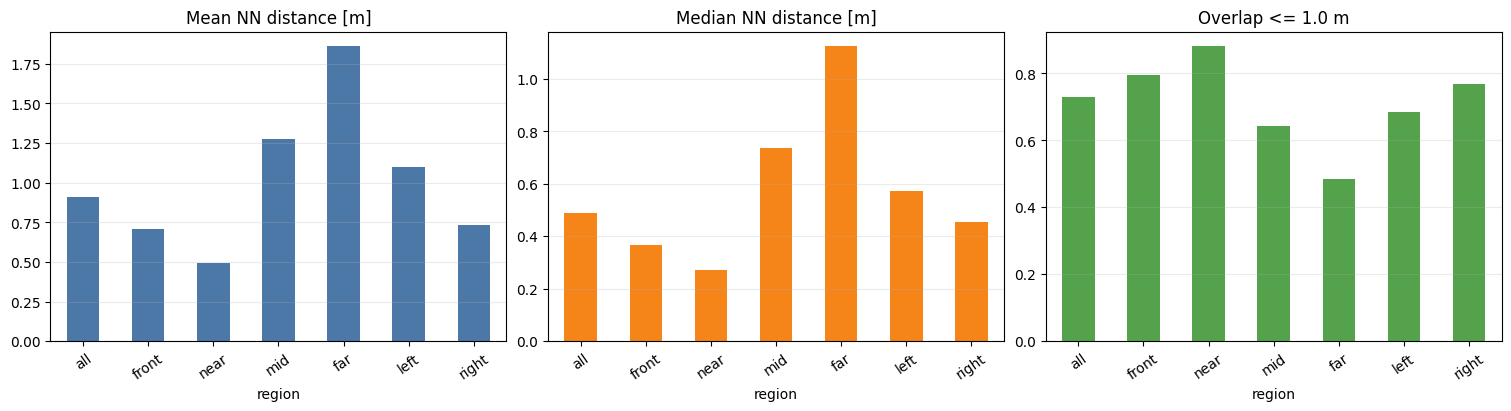

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
agg_df['mean_nn_m'].plot(kind='bar', ax=axes[0], color='#4C78A8', title='Mean NN distance [m]')
agg_df['median_nn_m'].plot(kind='bar', ax=axes[1], color='#F58518', title='Median NN distance [m]')
agg_df['overlap_ratio_1p0m'].plot(kind='bar', ax=axes[2], color='#54A24B', title='Overlap <= 1.0 m')
for ax in axes:
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
plt.show()

## Figura generada por el script

El script tambien guarda una figura PNG simple para usarla directamente en la memoria o en el README.

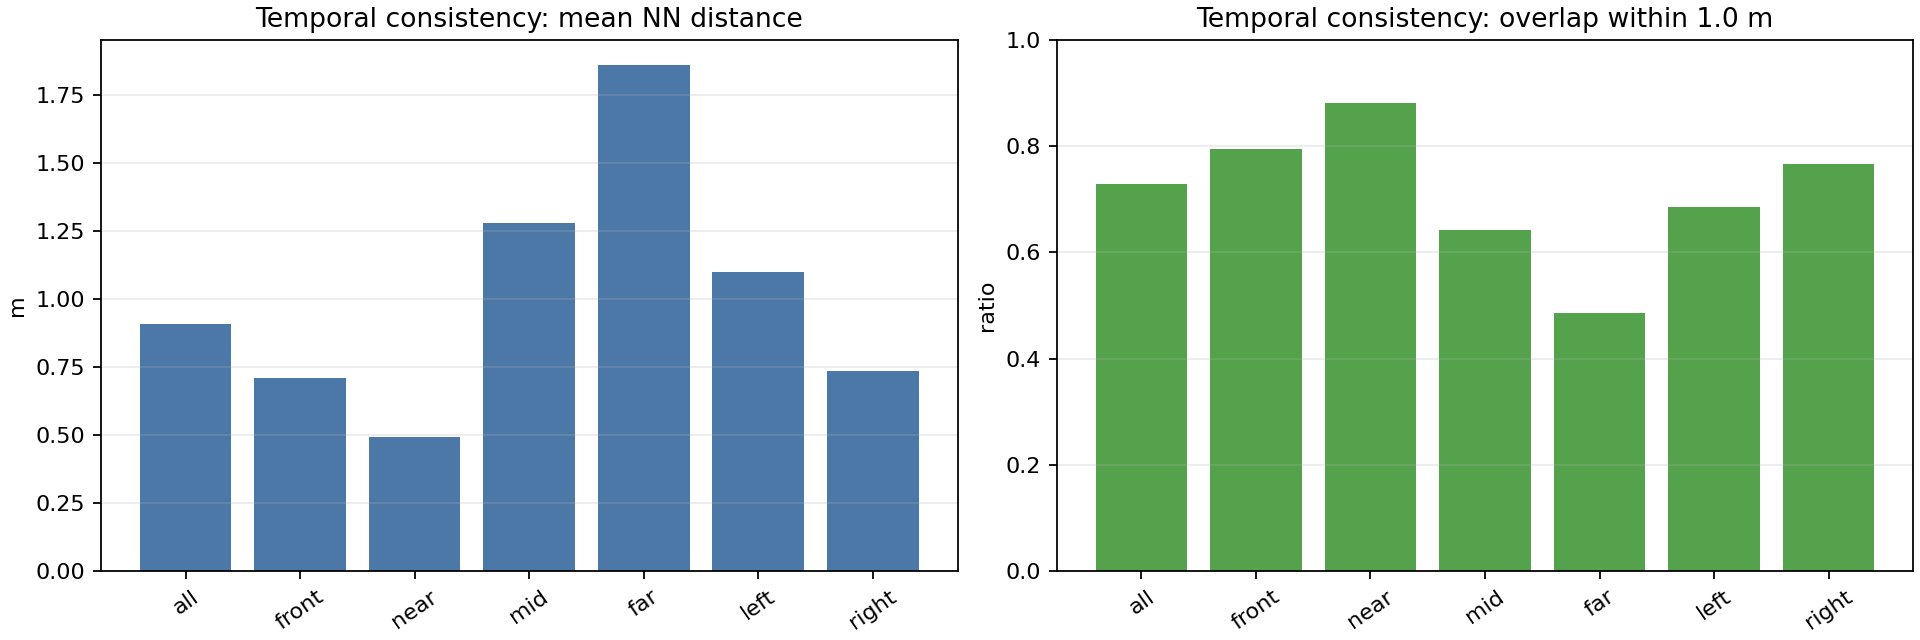

In [6]:
if FIGURE_PATH.exists():
    display(Image(filename=str(FIGURE_PATH)))
else:
    print('No se ha encontrado la figura:', FIGURE_PATH)

## Interpretacion

La consistencia temporal no mide si ICP estima bien la pose. Mide algo anterior: si dos pseudo-LiDAR consecutivas representan de forma parecida la misma escena cuando se alinean con la pose real.

Lectura esperada:
- si una region tiene buena consistencia temporal pero mal registro, el problema puede estar en el backend de registro;
- si una region tiene mala consistencia temporal, ICP parte de una representacion ya inestable;
- las zonas lejanas suelen ser mas fragiles porque pequenos errores de profundidad producen grandes desplazamientos 3D;
- una region frontal o cercana mas estable puede justificar por que ciertos subconjuntos funcionan mejor que el anillo completo.